# VGG-16 轻量化与边缘设备适配（FashionMNIST 教学案例）

**知识点简述**：VGG-16 是经典卷积网络，但参数量大、计算量高。轻量化改造（如通道缩放、深度可分离卷积、全局池化等）可以显著降低模型体积与推理开销，更适合边缘设备部署。

**设计意义**：通过对 VGG-16 的结构调整，兼顾精度与效率，帮助学生理解“模型压缩/高效网络”的核心思路，并掌握从数据读取、模型设计到训练评估的完整流程。

## 1. 环境与依赖
本案例使用 PyTorch 进行模型构建与训练，并使用 torchvision 读取 FashionMNIST 数据集。

In [32]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch version:", torch.__version__)

device: cuda
torch version: 2.7.1+cu118


## 2. 数据集读取与可视化
使用本地数据集路径 `D:\\xiangmu\\j18-VGG\\data`，并做必要的预处理与可视化检查。

train size: 60000
test size: 10000
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
batch shape: torch.Size([128, 1, 32, 32]) torch.Size([128])


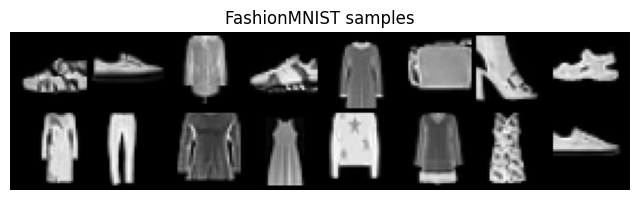

In [33]:
data_root = r"D:\xiangmu\j18-VGG\data"

if not os.path.isdir(data_root):
    raise FileNotFoundError(f"Data root not found: {data_root}")

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.FashionMNIST(root=data_root, train=True, download=False, transform=train_transform)
test_set = datasets.FashionMNIST(root=data_root, train=False, download=False, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print("train size:", len(train_set))
print("test size:", len(test_set))
print("classes:", train_set.classes)

images, labels = next(iter(train_loader))
print("batch shape:", images.shape, labels.shape)

grid = make_grid(images[:16], nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("FashionMNIST samples")
plt.show()

## 3. 轻量化 VGG-16 设计
改造思路：
- **通道缩放**：使用 `width_mult` 缩小每层通道数。
- **深度可分离卷积**：在中后期层替代普通卷积，降低参数与计算量。
- **全局平均池化**：降低全连接层参数量。

In [34]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size, stride, padding, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


def make_layers(in_channels, cfg, width_mult=0.5, use_depthwise_from_stage=3):
    layers = []
    stage = 1
    for v in cfg:
        if v == "M":
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            stage += 1
        else:
            out_ch = max(8, int(v * width_mult))
            if stage >= use_depthwise_from_stage:
                layers.append(DepthwiseSeparableConv(in_channels, out_ch))
            else:
                layers.append(ConvBlock(in_channels, out_ch))
            in_channels = out_ch
    return nn.Sequential(*layers)


class VGG16Lite(nn.Module):
    def __init__(self, num_classes=10, width_mult=0.5, use_depthwise_from_stage=3):
        super().__init__()
        cfg = [64, 64, "M", 128, 128, "M", 256, 256, 256, "M", 512, 512, 512, "M", 512, 512, 512, "M"]
        self.features = make_layers(1, cfg, width_mult, use_depthwise_from_stage)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(max(8, int(512 * width_mult)), 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = VGG16Lite(num_classes=10, width_mult=0.5, use_depthwise_from_stage=3).to(device)
print(model)
print("trainable params:", count_params(model))

VGG16Lite(
  (features): Sequential(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ConvBlock(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (4): ConvBlock(
      (net): Sequential(
        (0

## 4. 训练配置与流程
这里采用交叉熵损失和 Adam 优化器，训练若干轮用于教学演示。

In [35]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

In [36]:
epochs = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
    "lr": []
}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.6f}"
    )
    scheduler.step()

Epoch 1: train_loss=1.0918, train_acc=0.7208, test_loss=0.8768, test_acc=0.8292, lr=0.001000
Epoch 2: train_loss=0.8704, train_acc=0.8320, test_loss=0.8249, test_acc=0.8481, lr=0.000999
Epoch 3: train_loss=0.8146, train_acc=0.8595, test_loss=0.7859, test_acc=0.8679, lr=0.000996
Epoch 4: train_loss=0.7857, train_acc=0.8748, test_loss=0.7589, test_acc=0.8788, lr=0.000991
Epoch 5: train_loss=0.7646, train_acc=0.8834, test_loss=0.7539, test_acc=0.8849, lr=0.000984
Epoch 6: train_loss=0.7492, train_acc=0.8920, test_loss=0.7293, test_acc=0.8941, lr=0.000976
Epoch 7: train_loss=0.7379, train_acc=0.8968, test_loss=0.7121, test_acc=0.9030, lr=0.000965
Epoch 8: train_loss=0.7284, train_acc=0.9008, test_loss=0.7155, test_acc=0.9024, lr=0.000952
Epoch 9: train_loss=0.7193, train_acc=0.9049, test_loss=0.6976, test_acc=0.9082, lr=0.000938
Epoch 10: train_loss=0.7111, train_acc=0.9091, test_loss=0.7029, test_acc=0.9067, lr=0.000922
Epoch 11: train_loss=0.7056, train_acc=0.9110, test_loss=0.6853, test

### 训练曲线可视化
展示训练/测试集上的损失与准确率变化，便于观察收敛情况。

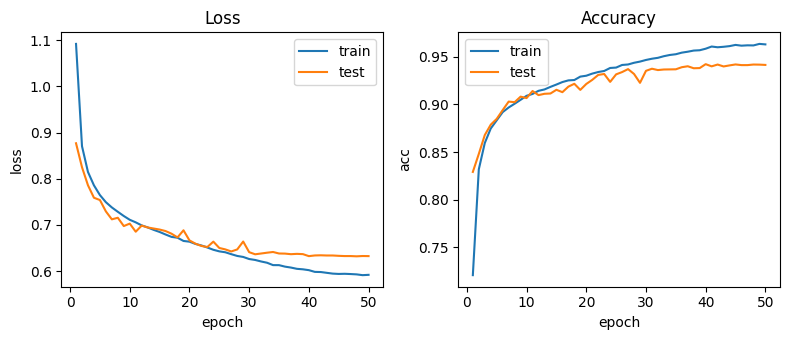

In [37]:
epochs_axis = range(1, epochs + 1)

plt.figure(figsize=(8, 3.5))
plt.subplot(1, 2, 1)
plt.plot(epochs_axis, history["train_loss"], label="train")
plt.plot(epochs_axis, history["test_loss"], label="test")
plt.title("Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, history["train_acc"], label="train")
plt.plot(epochs_axis, history["test_acc"], label="test")
plt.title("Accuracy")
plt.xlabel("epoch")
plt.ylabel("acc")
plt.legend()

plt.tight_layout()
plt.show()

### 效果分析与改进要点
从曲线看，训练集损失持续下降、测试集损失后期上升，说明出现过拟合。改进思路：
- **数据增强**：增加随机裁剪与水平翻转，提升泛化。
- **正则化**：使用 `AdamW` 的权重衰减抑制过拟合。
- **标签平滑**：降低过度自信，提高测试表现稳定性。
- **学习率调度**：使用余弦退火让训练后期更平滑收敛。

下面已加入上述改进，重新训练即可对比效果。

## 5. 评估与可视化预测
输出测试集精度，并展示若干样本的预测结果。

Final test accuracy: 0.9415


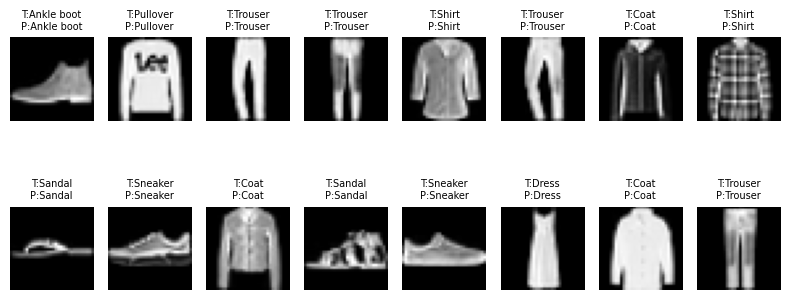

In [38]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final test accuracy: {test_acc:.4f}")

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

images_cpu = images[:16].cpu()
labels_cpu = labels[:16].cpu()
preds_cpu = preds[:16].cpu()

plt.figure(figsize=(8, 4))
for i in range(16):
    ax = plt.subplot(2, 8, i + 1)
    img = images_cpu[i] * 0.5 + 0.5
    plt.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(f"T:{train_set.classes[labels_cpu[i]]}\nP:{train_set.classes[preds_cpu[i]]}", fontsize=7)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 6. 轻量化效果对比（参数量与模型体积）
通过参数量与模型大小衡量轻量化效果，并与标准 VGG-16 做简单对比。

In [39]:
def model_size_mb(model):
    total_bytes = 0
    for v in model.state_dict().values():
        if torch.is_tensor(v):
            total_bytes += v.numel() * v.element_size()
    return total_bytes / (1024 ** 2)


def build_vgg16_standard(num_classes=10):
    cfg = [64, 64, "M", 128, 128, "M", 256, 256, 256, "M", 512, 512, 512, "M", 512, 512, 512, "M"]
    features = make_layers(1, cfg, width_mult=1.0, use_depthwise_from_stage=99)
    pool = nn.AdaptiveAvgPool2d((1, 1))
    classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(128, num_classes)
    )
    return nn.Sequential(features, pool, classifier)


vgg16_std = build_vgg16_standard()
print("VGG16-lite params:", count_params(model))
print("VGG16-lite size (MB):", round(model_size_mb(model), 2))
print("VGG16-standard params:", count_params(vgg16_std))
print("VGG16-standard size (MB):", round(model_size_mb(vgg16_std), 2))

VGG16-lite params: 523626
VGG16-lite size (MB): 2.03
VGG16-standard params: 14784714
VGG16-standard size (MB): 56.43


## 7. （可选）动态量化示例
量化可以进一步降低模型体积与推理延迟，这里演示对线性层进行动态量化。

In [40]:
model_cpu = model.to("cpu")
model_int8 = torch.quantization.quantize_dynamic(model_cpu, {nn.Linear}, dtype=torch.qint8)

print("FP32 size (MB):", round(model_size_mb(model_cpu), 2))
print("INT8 size (MB):", round(model_size_mb(model_int8), 2))

FP32 size (MB): 2.03
INT8 size (MB): 1.9


## 8. 拓展与思考（含解答思路）
1. **如果进一步减小 `width_mult`，精度下降明显怎么办？**
   - 思路：尝试知识蒸馏、数据增强、更长训练周期或引入轻量注意力（如 SE/ECANet）。
2. **把深度可分离卷积应用到所有层是否一定更好？**
   - 思路：前几层特征仍较“底层”，过度轻量化可能损失表达能力，可做分段替换对比实验。
3. **边缘设备部署时还要考虑哪些指标？**
   - 思路：除精度外，还需关注延迟、峰值内存、模型体积、能耗与硬件支持（如量化/算子支持）。
4. **如何把本模型迁移到彩色图像数据集？**
   - 思路：将输入通道改为 3，并调整归一化参数；其余结构可保持不变。